Found 4395 images belonging to 5 classes.
Found 775 images belonging to 5 classes.
Epoch 1/30
69/69 [==============================] - 55s 774ms/step - loss: 1.7342 - accuracy: 0.2319 - auc: 0.5370 - precision: 0.2603 - val_loss: 1.6001 - val_accuracy: 0.2310 - val_auc: 0.5547 - val_precision: 0.0000e+00 - lr: 0.0010
Epoch 2/30
69/69 [==============================] - 58s 834ms/step - loss: 1.5732 - accuracy: 0.2808 - auc: 0.6064 - precision: 0.4268 - val_loss: 1.5952 - val_accuracy: 0.2516 - val_auc: 0.5770 - val_precision: 0.0000e+00 - lr: 0.0010
Epoch 3/30
69/69 [==============================] - 56s 815ms/step - loss: 1.5569 - accuracy: 0.2969 - auc: 0.6240 - precision: 0.6149 - val_loss: 1.5985 - val_accuracy: 0.2181 - val_auc: 0.5596 - val_precision: 0.0000e+00 - lr: 0.0010
Epoch 4/30
69/69 [==============================] - 53s 762ms/step - loss: 1.5397 - accuracy: 0.3133 - auc: 0.6389 - precision: 0.6036 - val_loss: 1.5785 - val_accuracy: 0.2748 - val_auc: 0.5938 - val_precisio

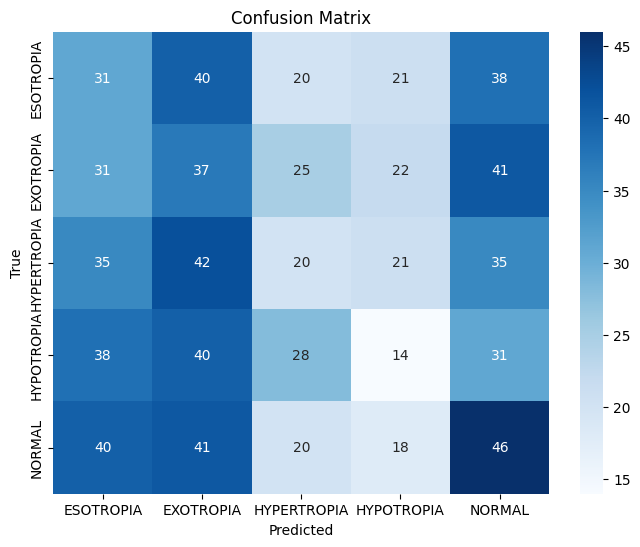

AlexNet model training and optimization complete.


In [5]:
import tensorflow as tf
import tensorflow_addons as tfa
import numpy as np
import cv2
import os
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, DepthwiseConv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D, Activation, Add
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import Callback, LearningRateScheduler, EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils.class_weight import compute_class_weight

# Define dataset path & parameters
data_dir = "E:/Projects/Strabismus/Denoised"
img_height, img_width = 227, 227
batch_size = 64
num_classes = 5  

# Advanced Data Augmentation
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.15,
    rotation_range=45,
    width_shift_range=0.3,
    height_shift_range=0.3,
    shear_range=0.3,
    zoom_range=0.3,
    horizontal_flip=True,
    brightness_range=[0.7, 1.3],
    fill_mode='nearest',
    featurewise_center=True,
    featurewise_std_normalization=True
)

datagen.mean = np.array([0.485, 0.456, 0.406])  # ImageNet mean

datagen.std = np.array([0.229, 0.224, 0.225])

train_generator = datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_generator = datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

# Compute class weights
class_weights = compute_class_weight('balanced', classes=np.arange(num_classes), y=train_generator.classes)
class_weight_dict = dict(enumerate(class_weights))

# Define Improved AlexNet model
def AlexNet(input_shape, num_classes):
    model = Sequential([
        Conv2D(96, (11, 11), strides=4, padding='same', activation='relu', input_shape=input_shape),
        BatchNormalization(),
        MaxPooling2D((3, 3), strides=2),
        
        DepthwiseConv2D((5, 5), padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling2D((3, 3), strides=2),
        
        Conv2D(384, (3, 3), padding='same', activation='relu'),
        Conv2D(384, (3, 3), padding='same', activation='relu'),
        Conv2D(256, (3, 3), padding='same', activation='relu'),
        MaxPooling2D((3, 3), strides=2),
        
        GlobalAveragePooling2D(),
        Dense(4096, activation='relu'),
        Dropout(0.5),
        Dense(4096, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])
    return model

# Instantiate model
model = AlexNet((img_height, img_width, 3), num_classes)

# Define learning rate scheduler
def lr_scheduler(epoch, lr):
    if epoch < 5:
        return lr
    elif epoch < 15:
        return lr * 0.5
    else:
        return lr * 0.1

callback_lr = LearningRateScheduler(lr_scheduler)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1)

# Use Lookahead Optimizer with AdamW
optimizer = tfa.optimizers.AdamW(learning_rate=0.001, weight_decay=1e-4)

# Compile model with Focal Loss
model.compile(optimizer=optimizer, 
              loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1), 
              metrics=['accuracy', tf.keras.metrics.AUC(name='auc'), tf.keras.metrics.Precision(name='precision')])

# Define early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the model
model.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator,
    class_weight=class_weight_dict,
    callbacks=[callback_lr, reduce_lr, early_stopping]
)

# Function to plot confusion matrix
def plot_confusion_matrix(model, generator):
    y_pred_probs = model.predict(generator)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = generator.classes
    
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=generator.class_indices.keys(), yticklabels=generator.class_indices.keys())
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

# Plot Confusion Matrix
plot_confusion_matrix(model, val_generator)

print("AlexNet model training and optimization complete.")